In [128]:
# !pip install langgraph

In [129]:
users = {
    "U001": {"name": "Aditi Rao", "department": "Engineering", "role": "Software Engineer", "status": "active"},
    "U002": {"name": "Rohan Mehta", "department": "Engineering", "role": "Senior Engineer", "status": "active"},
    "U003": {"name": "Fatima Sheikh", "department": "Finance", "role": "Analyst", "status": "active"},
    "U004": {"name": "Karan Verma", "department": "Finance", "role": "Manager", "status": "active"},
    "U005": {"name": "Neha Joshi", "department": "HR", "role": "HR Executive", "status": "active"},
    "U006": {"name": "Sameer Khan", "department": "Engineering", "role": "Intern", "status": "probation"},
    "U007": {"name": "Priya Nair", "department": "Security", "role": "Security Analyst", "status": "active"},
    "U008": {"name": "Vikram Singh", "department": "Sales", "role": "Sales Executive", "status": "active"},
    "U009": {"name": "Ananya Gupta", "department": "Engineering", "role": "Software Engineer", "status": "inactive"},
}

resources = {
    "R001": {
        "name": "Marketing Analytics Dashboard",
        "aliases": ["marketing dashboard", "analytics dashboard"],
        "sensitivity_tier": 1,
        "owner_department": "Marketing",
    },
    "R002": {
        "name": "Customer Support Ticketing Tool",
        "aliases": ["support tool", "ticketing tool", "zendesk-internal"],
        "sensitivity_tier": 1,
        "owner_department": "Support",
    },
    "R003": {
        "name": "Finance Reporting System",
        "aliases": ["finance reports", "fin reporting", "reporting system"],
        "sensitivity_tier": 2,
        "owner_department": "Finance",
    },
    "R004": {
        "name": "HR Payroll System",
        "aliases": ["payroll system", "payroll"],
        "sensitivity_tier": 3,
        "owner_department": "HR",
    },
    "R005": {
        "name": "Production Database - ReadOnly",
        "aliases": ["prod db readonly", "production read replica"],
        "sensitivity_tier": 3,
        "owner_department": "Engineering",
    },
    "R006": {
        "name": "Production Database - Admin",
        "aliases": ["prod db admin", "production admin access"],
        "sensitivity_tier": 4,
        "owner_department": "Engineering",
    },
    "R007": {
        "name": "Customer PII Vault",
        "aliases": ["pii vault", "customer data vault"],
        "sensitivity_tier": 4,
        "owner_department": "Security",
    },
    "R008": {
        "name": "Internal Wiki",
        "aliases": ["wiki", "confluence", "internal docs"],
        "sensitivity_tier": 1,
        "owner_department": "ALL",
    },
    "R009": {
        "name": "Sales Reporting System",
        "aliases": ["sales reports", "reporting system"],
        "sensitivity_tier": 2,
        "owner_department": "Sales",
    },
}

# Existing active access grants — list of (user_id, resource_id) pairs
existing_grants = [
    ("U002", "R003"),
    ("U008", "R001"),
]

policy_table = {
    "tier_1": {
        "rule": "auto_approve_if_duration_under_or_equal",
        "max_duration_days": 30,
        "otherwise": "manager_approval_required",
    },
    "tier_2": {
        "rule": "auto_approve_if_duration_under_or_equal_and_department_matches",
        "max_duration_days": 7,
        "otherwise": "manager_approval_required",
    },
    "tier_3": {
        "rule": "always",
        "outcome": "manager_approval_required",
    },
    "tier_4": {
        "rule": "always_unless_probation",
        "outcome": "security_approval_required",
        "probation_outcome": "rejected_probation",
    },
}

# Checks that apply BEFORE tier-based policy, in terms of precedence only —
# not prescribing implementation order or mechanism:
precedence_rules = {
    "inactive_user": {
        "condition": "requesting user's status == 'inactive'",
        "outcome": "rejected_invalid_user",
        "note": "must be checked regardless of which resource/tier is requested",
    },
    "duplicate_access": {
        "condition": "requesting user already holds active grant for the exact resource_id requested",
        "outcome": "duplicate_request",
        "note": "fires regardless of duration or stated justification in the new request",
    },
}

# Non-decision outcomes that arise from resolution failures, not policy application:
resource_resolutions = {
    "not_found": "resource reference matches nothing in the catalog",
    "clarification_required_ambiguous_resource": "resource reference matches multiple catalog entries with similar confidence — must list candidates",
    "clarification_required_missing_duration": "duration cannot be confidently determined from text — must not default",
}

# Deterministic unit conversion to days (must not depend on LLM arithmetic):
duration_unit_conversion = {
    "days": 1,
    "weeks": 7,
    "months": 30,
}

In [147]:
from langgraph.graph import START, END, StateGraph, MessagesState
from dotenv import load_dotenv

load_dotenv()


True

In [148]:
from langchain_groq import ChatGroq

model=ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0
)

In [149]:
from langchain.messages import AnyMessage
from langchain.tools import tool

from typing_extensions import Annotated, TypedDict
import operator
from pydantic import BaseModel
from typing import Literal

log=[]

class AccessFlowState(TypedDict):
    messages:Annotated[list[AnyMessage],operator.add]

    thread_id:str
    status:Literal["approval_pending","processing","completed","awaiting_clarification"]

    decision:str 
    user_id:str
    resource_id:str
    days:int
    reason:str
    resource_candidates: list[str]

class AccessRequestExtraction(BaseModel):
    user_id: str
    resource_reference: list[str]
    duration_value: int
    duration_unit: Literal["days", "weeks", "months"]
    thread_id:str

structured_model=model.with_structured_output(AccessRequestExtraction)


In [150]:
from langchain.messages import SystemMessage

# LLM Node

sys_prompt="You are an helpful assistant, your work is to extract the user id, resource reference strings for eg. 'Finance Reporting System' or 'customer data vault', raw duration string extracted as (unit,value) eg. ('weeks',2), ('days',3) or ('months', 1) if duration is not specified give the value as 0, extract the thread_id for every request"

def llm_call(state: AccessFlowState):
    try:
        message = structured_model.invoke(
            [
                SystemMessage(content=sys_prompt)
            ] + state["messages"]
        )

        return {
            "messages": [message],
            "llm_calls": state.get("llm_calls", 0) + 1
        }

    except Exception as e:
        print(e.message)

In [151]:
from langgraph.store.memory import InMemoryStore

store = InMemoryStore()

def update_store(thread_id: str, value):
    namespace = (thread_id, "request")
    store.put(namespace, "state", value)


def get_store(thread_id: str):
    namespace = (thread_id, "request")

    memories = store.search(namespace)

    if not memories:
        return None

    return memories[-1].value

In [152]:
def initiator(state: AccessFlowState):
    extraction = state["messages"][-1]

    return {
        "thread_id": extraction.thread_id,
        "user_id": extraction.user_id
    }

In [153]:
# validation node

from pydantic import BaseModel
from typing import Literal


class UserAuth(BaseModel):
    exists: bool = False
    status: Literal["active", "inactive", "probation"] = "inactive"


def user_authenticator_and_status_checker(user_id: str) -> UserAuth:
    """Checks whether the user exists and returns their status."""
    if user_id not in users:
        return UserAuth()

    return UserAuth(
        exists=True,
        status=users[user_id]["status"]
    )

def normalize_resource_reference(text: str) -> str:
    return " ".join(
        text.lower()
        .strip()
        .split()
    )

def resource_identifier(resource_name: str) -> list[str]:
    query = normalize_resource_reference(resource_name)

    matches = []

    for resource_id, resource in resources.items():
        name = normalize_resource_reference(resource["name"])

        aliases = [
            normalize_resource_reference(alias)
            for alias in resource["aliases"]
        ]

        if query == name or query in aliases:
            matches.append(resource_id)

    return matches


def duration_to_days(unit: Literal["days", "weeks", "months"], value: int) -> int:
    """Converts a duration into days deterministically."""
    duration_unit_conversion = {
        "days": 1,
        "weeks": 7,
        "months": 30
    }

    return value * duration_unit_conversion[unit]

def validator(state: AccessFlowState) -> dict:
    extraction = state["messages"][-1]
    user_id = extraction.user_id
    resource_refs = extraction.resource_reference
    value, unit = extraction.duration_value, extraction.duration_unit

    update = {"status": "completed", "user_id": user_id}

    user_form = user_authenticator_and_status_checker(user_id)
    if not user_form.exists:
        update.update(decision="rejected_invalid_user", reason="user_not_found")
        update_store(state["thread_id"], {**state, **update}); return update
    if user_form.status == "inactive":
        update.update(decision="rejected_invalid_user", reason="user_inactive")
        update_store(state["thread_id"], {**state, **update}); return update

    # Reuse an already-resolved resource instead of re-deriving from a
    # follow-up message that may not mention it at all.
    if state.get("resource_id"):
        resource_ids = [state["resource_id"]]
    elif resource_refs:
        resource_ids = []
        for ref in resource_refs:
            resource_ids.extend(resource_identifier(ref))
        resource_ids = list(dict.fromkeys(resource_ids))
    else:
        resource_ids = []

    # Resolve duration BEFORE any early return, so it's never silently lost.
    days = duration_to_days(unit, value) if value > 0 else state.get("days")
    if days:
        update["days"] = days

    if len(resource_ids) == 0:
        update.update(decision="not_found", reason="resource_not_found", resource_candidates=[])
        update_store(state["thread_id"], {**state, **update}); return update

    if len(resource_ids) > 1:
        update.update(status="awaiting_clarification", decision="clarification_required",
                       reason="clarification_required_ambiguous_resource", resource_candidates=resource_ids)
        update_store(state["thread_id"], {**state, **update}); return update

    update["resource_id"] = resource_ids[0]

    if not days:
        update.update(status="awaiting_clarification", decision="clarification_required",
                       reason="clarification_required_missing_duration", resource_candidates=[])
        update_store(state["thread_id"], {**state, **update}); return update

    update.update(status="processing", decision="validation_passed", reason="", resource_candidates=[], days=days)
    update_store(state["thread_id"], {**state, **update})
    return update

In [154]:
# double access checker node

def has_grant(user_id: str, resource_id: str) -> bool:
    """Checks whether the user already has active access."""
    return (user_id, resource_id) in existing_grants


def duplicate_checker(state: AccessFlowState):
    user_id = state["user_id"]
    resource_id = state["resource_id"]

    update={
        "status":"processing"
    }

    if has_grant(user_id, resource_id):
        update["decision"]="duplicate_request"
        update["reason"]="user_already_has_active_access"
        update["status"]="completed"

        update_store(state["thread_id"],{**state,**update})

        return update
    
    update_store(state["thread_id"],{**state,**update})

    return {}

In [155]:
def policy_resolver(state: AccessFlowState):
    resource_id, duration, user_id, thread_id = state["resource_id"], state["days"], state["user_id"], state["thread_id"]
    user_status = users[user_id]["status"]
    user_department = users[user_id]["department"]
    resource = resources[resource_id]
    owner_department, tier = resource["owner_department"], resource["sensitivity_tier"]

    decision, reason, status = "no_tier_found", "no_appropriate_tier_found", "completed"

    if tier == 1:
        decision, reason, status = ("auto-approved", "tier_1_duration_within_limit", "completed") if duration <= 30 \
            else ("manager_approval_required", "tier_1_duration_exceeds_limit", "approval_pending")
    elif tier == 2:
        decision, reason, status = ("auto-approved", "tier_2_duration_and_department_match", "completed") \
            if duration <= 7 and user_department == owner_department \
            else ("manager_approval_required", "tier_2_duration_or_department_requirement_not_met", "approval_pending")
    elif tier == 3:
        decision, reason, status = "manager_approval_required", "tier_3_requires_manager_approval", "approval_pending"
    elif tier == 4:
        decision, reason, status = ("rejected_probation", "probation_user_cannot_request_tier_4_access", "completed") \
            if user_status == "probation" \
            else ("security_approval_required", "tier_4_requires_security_approval", "approval_pending")

    update = {"decision": decision, "reason": reason, "status": status}
    if status == "approval_pending":
        update["approval_id"] = submit_approval(thread_id, user_id, resource_id, duration, decision)

    update_store(thread_id, {**state, **update})
    return update

In [156]:
class LogEntry(BaseModel):
    user_id: str
    resource_id: str | None = None
    resource_candidates: list[str] = []
    decision: str = ""
    reason: str = ""


def log_updater(state: AccessFlowState) -> dict:
    """Creates one log entry for every processed request."""

    log_entry = LogEntry(
        user_id=state.get("user_id", ""),
        resource_id=state.get("resource_id"),
        resource_candidates=state.get("resource_candidates", []),
        decision=state.get("decision", ""),
        reason=state.get("reason", "")
    )

    log.append(log_entry)

    print(log_entry)

    return {}

In [157]:
def approval_handler(state: AccessFlowState):
    approval_id = state["approval_id"]
    outcome = state.get("outcome")
    pending = approval_store.get(approval_id)

    if pending is None:
        return {"decision": "invalid_approval_reference", "reason": "approval_id_not_found", "status": "completed"}
    if outcome == "approved":
        decision, reason = "approved", "approval_granted"
    elif outcome == "denied":
        decision, reason = "denied", "approval_denied"
    else:
        return {"decision": "invalid_approval_response", "reason": "unsupported_approval_outcome", "status": "completed"}

    result = {**pending, "decision": decision, "reason": reason, "status": "completed"}
    update_store(pending["thread_id"], result)   # was missing — thread stays "approval_pending" forever otherwise
    return result

In [158]:
def clarification_handler(state: AccessFlowState):

    thread_id = state["thread_id"]

    previous = get_store(thread_id)
    extraction = state["messages"][-1]

    update = {
        "thread_id": thread_id,
        "user_id": previous["user_id"],
        "status": "processing",
    }

    # Preserve resource if it was already resolved
    if previous.get("resource_id"):
        update["resource_id"] = previous["resource_id"]

    # Preserve candidates if ambiguity still matters
    if previous.get("resource_candidates"):
        update["resource_candidates"] = previous["resource_candidates"]

    # New duration from follow-up
    if extraction.duration_value > 0:
        update["days"] = duration_to_days(
            extraction.duration_unit,
            extraction.duration_value
        )
    elif previous.get("days"):
        update["days"] = previous["days"]    

    # If resource was missing/ambiguous, resolve the new reference
    if extraction.resource_reference:

        resource_ids = []

        for resource_ref in extraction.resource_reference:
            resource_ids.extend(
                resource_identifier(resource_ref)
            )

        resource_ids = list(dict.fromkeys(resource_ids))

        if len(resource_ids) == 1:
            update["resource_id"] = resource_ids[0]
            update["resource_candidates"] = []

    return update

In [159]:
approval_store = {}
_approval_counter = 0

def submit_approval(thread_id, user_id, resource_id, days, approval_type):
    global _approval_counter
    _approval_counter += 1
    approval_id = f"AP-{_approval_counter:03d}"
    approval_store[approval_id] = {
        "thread_id": thread_id, "user_id": user_id,
        "resource_id": resource_id, "days": days, "approval_type": approval_type,
    }
    return approval_id

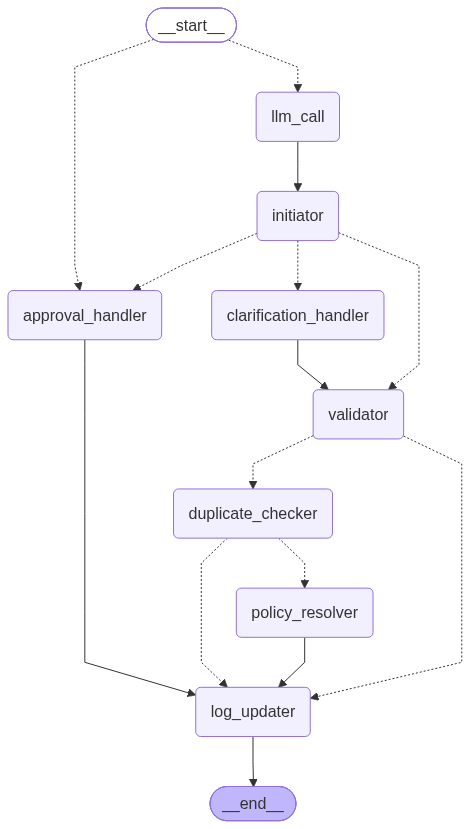

In [160]:
from langgraph.graph import StateGraph, START, END

agent_graph=StateGraph(AccessFlowState)

# add nodes here
agent_graph.add_node("llm_call",llm_call)
agent_graph.add_node("initiator",initiator)
agent_graph.add_node("approval_handler",approval_handler)
agent_graph.add_node("clarification_handler",clarification_handler)
agent_graph.add_node("validator",validator)
agent_graph.add_node("duplicate_checker",duplicate_checker)
agent_graph.add_node("policy_resolver",policy_resolver)
agent_graph.add_node("log_updater",log_updater)

def entry_router(state: AccessFlowState) -> Literal["llm_call", "approval_handler"]:
    return "approval_handler" if state.get("approval_id") else "llm_call"

def validator_conditional_router(state:AccessFlowState)->Literal["duplicate_checker","log_updater"]:
    if state["decision"] == "validation_passed":
        return "duplicate_checker"
    else: return "log_updater"

def duplicate_checker_conditional_router(state:AccessFlowState)->Literal["policy_resolver","log_updater"]:
    if state["decision"] == "validation_passed":
        return "policy_resolver"
    else: return "log_updater"

def initiator_conditional_router(
    state: AccessFlowState
) -> Literal["validator", "approval_handler"]:

    thread_id = state["thread_id"]
    prev_state = get_store(thread_id)

    if prev_state is not None and prev_state["status"] == "approval_pending":
        return "approval_handler"

    if prev_state is not None and prev_state["status"] == "awaiting_clarification":
        return "clarification_handler"

    return "validator"

# add edges
agent_graph.add_conditional_edges(START, entry_router, ["llm_call", "approval_handler"])
agent_graph.add_edge("llm_call", "initiator")
agent_graph.add_conditional_edges(
    "initiator",
    initiator_conditional_router,
    ["validator","approval_handler","clarification_handler"]
)
agent_graph.add_edge("approval_handler","log_updater")
agent_graph.add_edge("clarification_handler","validator")
agent_graph.add_conditional_edges(
    "validator",
    validator_conditional_router,
    ["duplicate_checker","log_updater"]
)
agent_graph.add_conditional_edges(
    "duplicate_checker",
    duplicate_checker_conditional_router,
    ["log_updater","policy_resolver"]
)
agent_graph.add_edge("policy_resolver", "log_updater")
agent_graph.add_edge("log_updater", END)

# compile the agent
agent=agent_graph.compile(store=store)

# Show the agent
from IPython.display import Image, display
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))


In [161]:
from langchain.messages import HumanMessage
interleaved_events = [
    {"thread_id": "T1", "user_id": "U003", "text": "I need finance reporting system access for a while."},
    {"thread_id": "T2", "user_id": "U001", "text": "I need access to the reporting system for 5 days."},
    {"thread_id": "T3", "user_id": "U007", "text": "PII vault for 3 days"},
    {"thread_id": "T1", "user_id": "U003", "text": "10 days."},
    {"thread_id": "T2", "user_id": "U001", "text": "the finance one."},
    {"thread_id": "T4", "user_id": "U008", "text": "Requesting admin access to production database for a demo."},
    {"thread_id": "T5", "user_id": "U008", "text": "I need wiki access for 5 days."},
    {"thread_id": "T99", "user_id": "U001", "text": "10 days."},
]

for t in interleaved_events:
    agent.invoke({"messages": [HumanMessage(content=f"{t['user_id']}, {t['thread_id']}: {t['text']}")]})

submitted_ids = list(approval_store.keys())   # real submission order
approval_response_events = [
    {"approval_id": submitted_ids[0], "outcome": "approved"},
    {"approval_id": submitted_ids[1], "outcome": "denied"},
    {"approval_id": submitted_ids[2], "outcome": "approved"},
    {"approval_id": "AP-999", "outcome": "approved"},
]
for e in approval_response_events:
    agent.invoke(e)

user_id='U003' resource_id='R003' resource_candidates=[] decision='clarification_required' reason='clarification_required_missing_duration'
user_id='U001' resource_id=None resource_candidates=['R003', 'R009'] decision='clarification_required' reason='clarification_required_ambiguous_resource'
user_id='U007' resource_id='R007' resource_candidates=[] decision='security_approval_required' reason='tier_4_requires_security_approval'
user_id='U003' resource_id='R003' resource_candidates=[] decision='manager_approval_required' reason='tier_2_duration_or_department_requirement_not_met'
user_id='U001' resource_id='R003' resource_candidates=[] decision='manager_approval_required' reason='tier_2_duration_or_department_requirement_not_met'
user_id='U008' resource_id=None resource_candidates=[] decision='not_found' reason='resource_not_found'
user_id='U008' resource_id='R008' resource_candidates=[] decision='auto-approved' reason='tier_1_duration_within_limit'
user_id='U001' resource_id=None resour

IndexError: list index out of range

In [ ]:
log

[LogEntry(user_id='U003', resource_id='R003', resource_candidates=[], decision='clarification_required', reason='clarification_required_missing_duration'),
 LogEntry(user_id='U003', resource_id=None, resource_candidates=[], decision='not_found', reason='resource_not_found'),
 LogEntry(user_id='U001', resource_id=None, resource_candidates=['R003', 'R009'], decision='clarification_required', reason='clarification_required_ambiguous_resource'),
 LogEntry(user_id='U001', resource_id='R003', resource_candidates=[], decision='clarification_required', reason='clarification_required_missing_duration'),
 LogEntry(user_id='U003', resource_id='R003', resource_candidates=[], decision='clarification_required', reason='clarification_required_missing_duration'),
 LogEntry(user_id='U003', resource_id=None, resource_candidates=[], decision='not_found', reason='resource_not_found'),
 LogEntry(user_id='U001', resource_id=None, resource_candidates=['R003', 'R009'], decision='clarification_required', reaso